<a href="https://colab.research.google.com/github/zyf-hitsz/PytorchLearning/blob/main/%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/%E5%8D%B7%E7%A7%AF%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/AlexNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#深度卷积神经网络
##AlexNet
AlexNet首次证明了学习到的特征可以超越手工设计的特征，它使用了8层卷积神经网络，下面是一个精简版的AlexNet。*注意：最上层全连接层的参数是10，这里的1000是错的。*
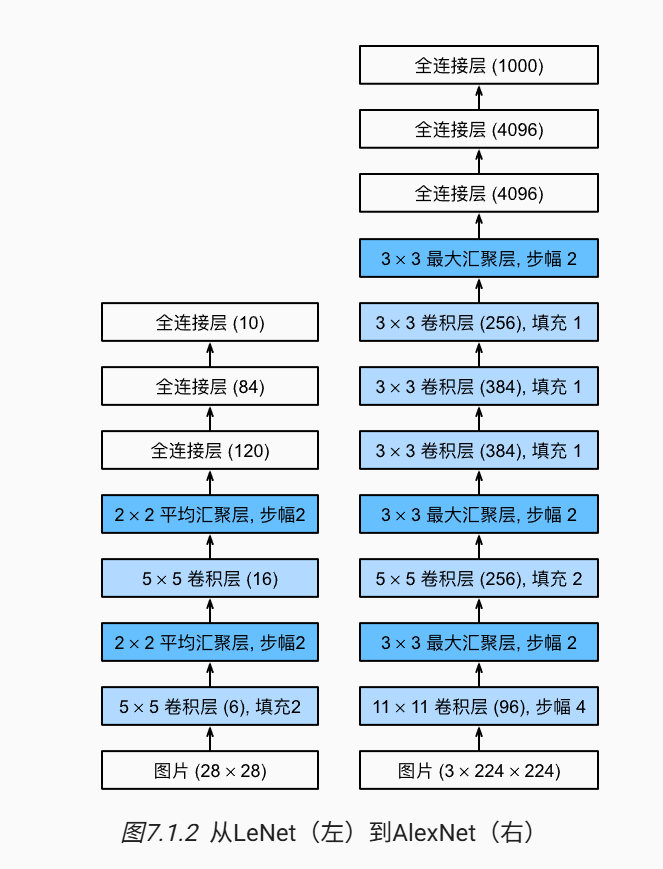

相比于LetNet，AlexNet层数更多，训练更深，使用了更多的卷积层和更多的参数来拟合大规模的ImageNet数据集，也更昂贵。今天，AlexNet已经被更有效的架构所超越，但它是从浅层网络到深层网络的关键一步。Dropout、ReLU和预处理是提升计算机视觉任务性能的其他关键步骤。

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 162kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.1MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Training on: cuda:0


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [1/40] | Loss: 1.5346 | Train Acc: 0.4447 | Test Acc: 0.7356
Epoch [2/40] | Loss: 0.6662 | Train Acc: 0.7508 | Test Acc: 0.7972
Epoch [3/40] | Loss: 0.5441 | Train Acc: 0.7991 | Test Acc: 0.8255
Epoch [4/40] | Loss: 0.4760 | Train Acc: 0.8255 | Test Acc: 0.8430
Epoch [5/40] | Loss: 0.4317 | Train Acc: 0.8415 | Test Acc: 0.8395
Epoch [6/40] | Loss: 0.4006 | Train Acc: 0.8526 | Test Acc: 0.8587
Epoch [7/40] | Loss: 0.3758 | Train Acc: 0.8635 | Test Acc: 0.8635
Epoch [8/40] | Loss: 0.3588 | Train Acc: 0.8691 | Test Acc: 0.8728
Epoch [9/40] | Loss: 0.3428 | Train Acc: 0.8726 | Test Acc: 0.8775
Epoch [10/40] | Loss: 0.3292 | Train Acc: 0.8785 | Test Acc: 0.8656
Epoch [11/40] | Loss: 0.3193 | Train Acc: 0.8816 | Test Acc: 0.8830
Epoch [12/40] | Loss: 0.3083 | Train Acc: 0.8862 | Test Acc: 0.8871
Epoch [13/40] | Loss: 0.2984 | Train Acc: 0.8906 | Test Acc: 0.8914
Epoch [14/40] | Loss: 0.2911 | Train Acc: 0.8933 | Test Acc: 0.8934
Epoch [15/40] | Loss: 0.2820 | Train Acc: 0.8958 | Test A

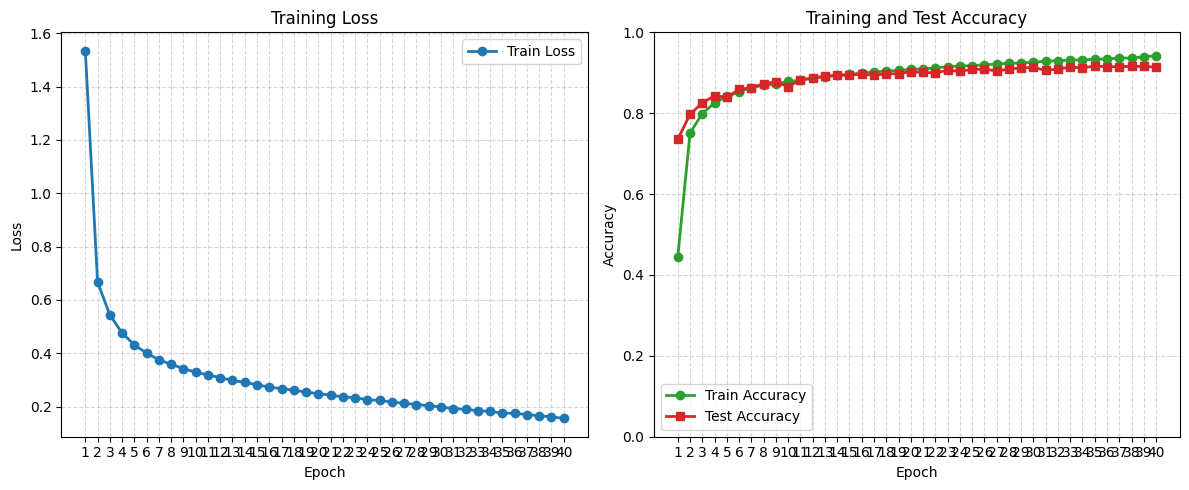

训练曲线已保存为 alexnet_training_curves.png


In [1]:
# @title
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


# ===================== 1. AlexNet模型 =====================

# 网络结构与D2L原代码保持一致
net = nn.Sequential(
    # 使用11×11的卷积窗口，步幅为4
    nn.Conv2d(
        in_channels=1,
        out_channels=96,
        kernel_size=11,
        stride=4,
        padding=1
    ),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    # 使用5×5卷积窗口，填充为2
    nn.Conv2d(
        in_channels=96,
        out_channels=256,
        kernel_size=5,
        padding=2
    ),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    # 三个连续的卷积层
    nn.Conv2d(
        in_channels=256,
        out_channels=384,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    nn.Conv2d(
        in_channels=384,
        out_channels=384,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    nn.Conv2d(
        in_channels=384,
        out_channels=256,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),

    # 全连接层
    nn.Linear(6400, 4096),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(4096, 10)
)


# ===================== 2. 加载数据 =====================

def load_data_fashion_mnist(batch_size, resize=None):
    """
    替代d2l.load_data_fashion_mnist。

    数据处理：
    1. 将28×28图片缩放到224×224
    2. 转换成Tensor
    3. 将像素值从0～255缩放到0～1
    """

    transform_list = []

    if resize is not None:
        transform_list.append(transforms.Resize(resize))

    transform_list.append(transforms.ToTensor())

    transform = transforms.Compose(transform_list)

    train_dataset = datasets.FashionMNIST(
        root="./data",
        train=True,
        transform=transform,
        download=True
    )

    test_dataset = datasets.FashionMNIST(
        root="./data",
        train=False,
        transform=transform,
        download=True
    )

    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4
    )

    test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4
    )

    return train_loader, test_loader


# ===================== 3. 准确率计算 =====================

def accuracy(y_hat, y):
    """计算一个批次中预测正确的样本数。"""

    predictions = y_hat.argmax(dim=1)

    correct = (predictions == y).sum()

    return correct.item()


# ===================== 4. 测试集评估 =====================

@torch.no_grad()
def evaluate_accuracy_gpu(net, data_iter, device):
    """计算模型在测试集上的准确率。"""

    net.eval()

    correct_sum = 0
    sample_count = 0

    for X, y in data_iter:
        X = X.to(device)
        y = y.to(device)

        y_hat = net(X)

        correct_sum += accuracy(y_hat, y)
        sample_count += y.numel()

    return correct_sum / sample_count


# ===================== 5. 训练函数 =====================

def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """
    替代d2l.train_ch6。

    训练方式与D2L原代码保持一致：
    1. Xavier权重初始化
    2. SGD优化器
    3. 交叉熵损失函数
    """

    def init_weights(module):
        # D2L的train_ch6只初始化权重，不修改偏置
        if type(module) == nn.Linear or type(module) == nn.Conv2d:
            nn.init.xavier_uniform_(module.weight)

    net.apply(init_weights)
    net.to(device)

    optimizer = torch.optim.SGD(
        net.parameters(),
        lr=lr
    )

    loss_function = nn.CrossEntropyLoss()

    print(f"Training on: {device}")

    # 保存每个epoch的训练结果
    history = {
        "train_loss": [],
        "train_acc": [],
        "test_acc": []
    }

    for epoch in range(num_epochs):
        net.train()

        loss_sum = 0.0
        correct_sum = 0
        sample_count = 0

        for X, y in train_iter:
            X = X.to(device)
            y = y.to(device)

            # 清空梯度
            optimizer.zero_grad()

            # 前向传播
            y_hat = net(X)

            # 计算损失
            loss = loss_function(y_hat, y)

            # 反向传播
            loss.backward()

            # 更新模型参数
            optimizer.step()

            # 统计训练指标
            with torch.no_grad():
                batch_size = X.shape[0]

                loss_sum += loss.item() * batch_size
                correct_sum += accuracy(y_hat, y)
                sample_count += batch_size

        # 当前epoch的平均训练损失
        train_loss = loss_sum / sample_count

        # 当前epoch的训练准确率
        train_acc = correct_sum / sample_count

        # 当前epoch的测试准确率
        test_acc = evaluate_accuracy_gpu(
            net,
            test_iter,
            device
        )

        # 保存当前epoch的训练结果
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] | "
            f"Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Test Acc: {test_acc:.4f}"
        )

    return history


# ===================== 6. 绀制训练曲线 =====================

def plot_history(history):
    """绘制损失和准确率随epoch变化的曲线。"""

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # ---------- 训练损失曲线 ----------

    plt.subplot(1, 2, 1)

    plt.plot(
        epochs,
        history["train_loss"],
        color="tab:blue",
        marker="o",
        linewidth=2,
        label="Train Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.xticks(epochs)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    # ---------- 准确率曲线 ----------

    plt.subplot(1, 2, 2)

    plt.plot(
        epochs,
        history["train_acc"],
        color="tab:green",
        marker="o",
        linewidth=2,
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        history["test_acc"],
        color="tab:red",
        marker="s",
        linewidth=2,
        label="Test Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Test Accuracy")
    plt.xticks(epochs)
    plt.ylim(0, 1)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.tight_layout()

    # 保存曲线图片
    plt.savefig(
        "alexnet_training_curves.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("训练曲线已保存为 alexnet_training_curves.png")


# ===================== 7. 主程序 =====================

def main():
    # 与D2L原代码的参数完全一致
    batch_size = 128
    lr = 0.01
    num_epochs = 40

    # 加载Fashion-MNIST，并放大到224×224
    train_iter, test_iter = load_data_fashion_mnist(
        batch_size=batch_size,
        resize=224
    )

    # 等价于d2l.try_gpu()
    device = torch.device(
        "cuda:0" if torch.cuda.is_available() else "cpu"
    )

    # 训练模型
    history = train_ch6(
        net=net,
        train_iter=train_iter,
        test_iter=test_iter,
        num_epochs=num_epochs,
        lr=lr,
        device=device
    )

    # 绘制训练曲线
    plot_history(history)


if __name__ == "__main__":
    main()

可以看到loss一开始下降就很快，但是由于学习率只有0.01，需要训练很多epochs才能接近网络的极限能力，40个epochs也还明显没有达到test acc的上限，训练开销太大。其实对于Fashion-MNIST数据集来说，AlexNet太复杂了，增加了大量的训练成本换来的提升是比较小的。